In [3]:
# ============================================
# 美股科技巨头股票与财务分析
# 数据来源: WRDS (CRSP + Compustat)
# ============================================

import wrds
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# 连接WRDS
db = wrds.Connection()
print("WRDS连接成功！")

# 定义股票代码 (PERMNO)
stocks = {
    'AAPL': 14593,  # Apple
    'MSFT': 10107,  # Microsoft
    'GOOGL': 14542  # Google (Alphabet)
}

# 获取2023-2025年的股票数据
query = """
SELECT date, permno, prc, ret, vol
FROM crsp.dsf
WHERE permno IN (14593, 10107, 14542)
AND date >= '2023-01-01'
ORDER BY date, permno
"""

df_stock = db.raw_sql(query, date_cols=['date'])
print(f"获取数据: {len(df_stock)} 条记录")
print(df_stock.head(10))

Loading library list...
Done
WRDS连接成功！
获取数据: 1506 条记录
        date  permno        prc       ret          vol
0 2023-01-03   10107     239.58 -0.001001   25723760.0
1 2023-01-03   14542       89.7  0.010932   20710597.0
2 2023-01-03   14593     125.07 -0.037405  111953221.0
3 2023-01-04   10107  229.10001 -0.043743   50564994.0
4 2023-01-04   14542      88.71 -0.011037   26980137.0
5 2023-01-04   14593     126.36  0.010314   89022192.0
6 2023-01-05   10107     222.31 -0.029638   39541865.0
7 2023-01-05   14542      86.77 -0.021869   23110412.0
8 2023-01-05   14593     125.02 -0.010605   81128113.0
9 2023-01-06   10107  224.92999  0.011785   43569634.0


In [4]:
# 添加股票名称列
permno_to_name = {14593: 'AAPL', 10107: 'MSFT', 14542: 'GOOGL'}
df_stock['ticker'] = df_stock['permno'].map(permno_to_name)

# 查看数据
print(df_stock.head())

        date  permno        prc       ret          vol ticker
0 2023-01-03   10107     239.58 -0.001001   25723760.0   MSFT
1 2023-01-03   14542       89.7  0.010932   20710597.0  GOOGL
2 2023-01-03   14593     125.07 -0.037405  111953221.0   AAPL
3 2023-01-04   10107  229.10001 -0.043743   50564994.0   MSFT
4 2023-01-04   14542      88.71 -0.011037   26980137.0  GOOGL


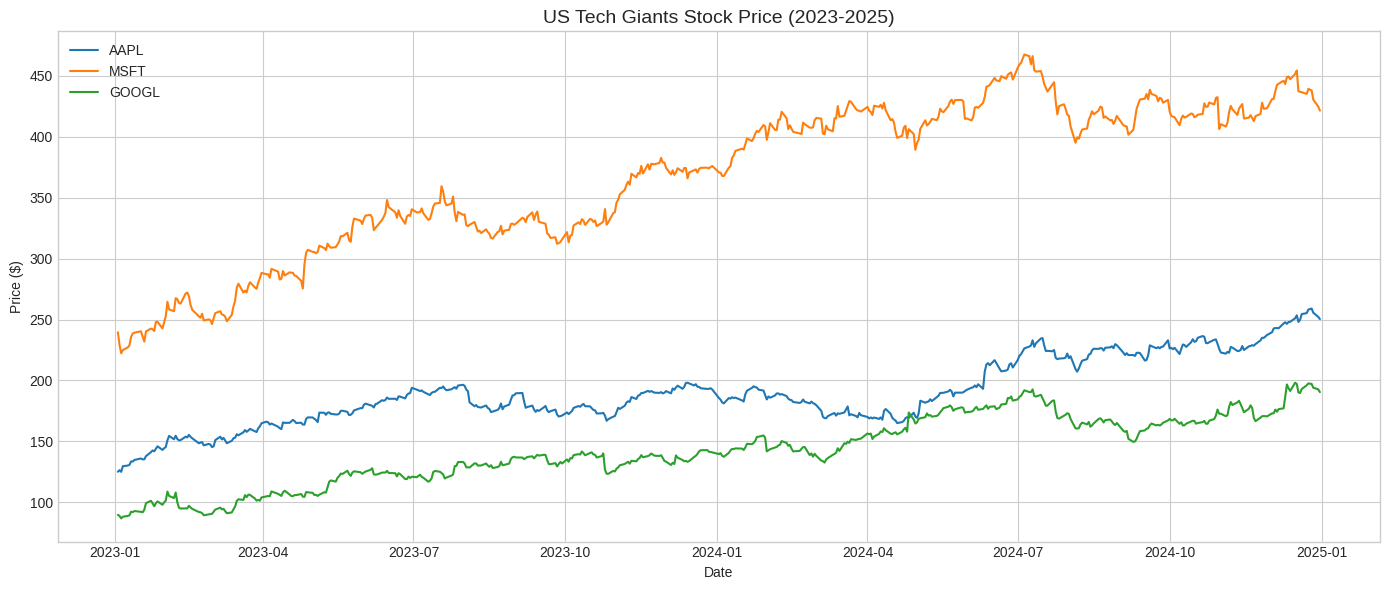

图表已保存: stock_price_trend.png


In [5]:
# 设置图表风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 6))

# 绘制三只股票的走势
for ticker in ['AAPL', 'MSFT', 'GOOGL']:
    stock_data = df_stock[df_stock['ticker'] == ticker]
    plt.plot(stock_data['date'], stock_data['prc'], label=ticker, linewidth=1.5)

plt.title('US Tech Giants Stock Price (2023-2025)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()

# 保存图表
plt.savefig('stock_price_trend.png', dpi=150)
plt.show()

print("图表已保存: stock_price_trend.png")

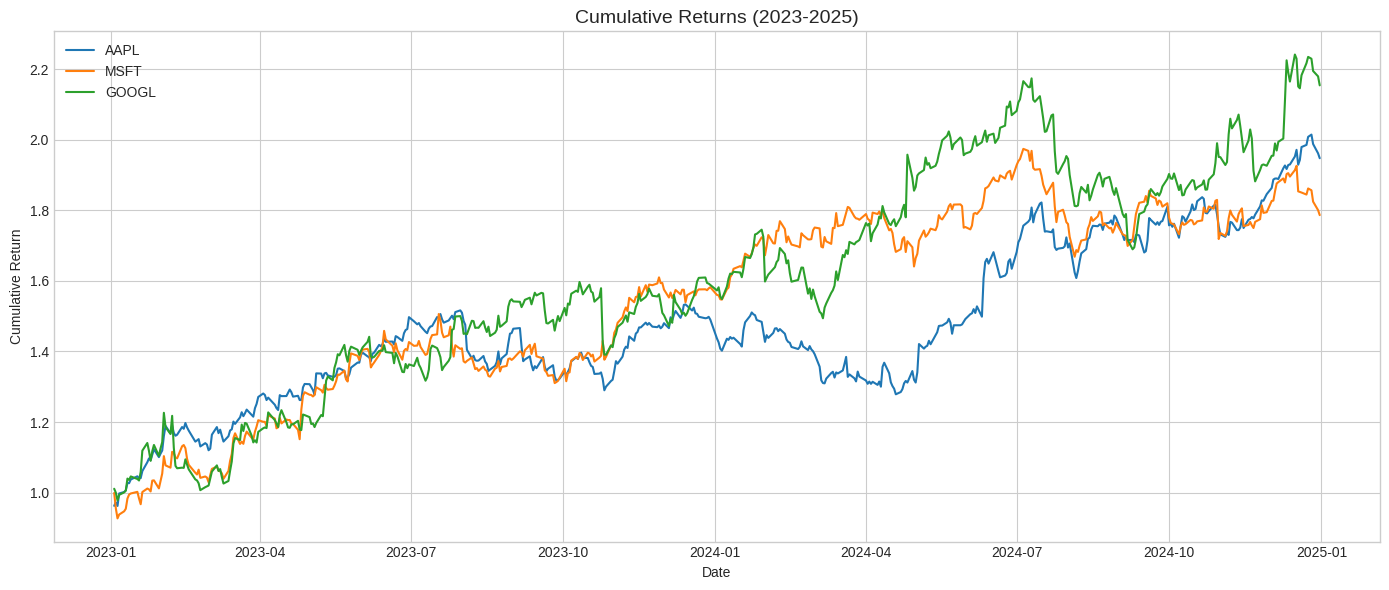

图表已保存: cumulative_returns.png


In [6]:
# 计算累计收益率
plt.figure(figsize=(14, 6))

for ticker in ['AAPL', 'MSFT', 'GOOGL']:
    stock_data = df_stock[df_stock['ticker'] == ticker].copy()
    stock_data = stock_data.sort_values('date')
    stock_data['cum_ret'] = (1 + stock_data['ret'].fillna(0)).cumprod()
    plt.plot(stock_data['date'], stock_data['cum_ret'], label=ticker, linewidth=1.5)

plt.title('Cumulative Returns (2023-2025)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.tight_layout()

plt.savefig('cumulative_returns.png', dpi=150)
plt.show()

print("图表已保存: cumulative_returns.png")

In [7]:
# 计算每只股票的关键指标
summary = []

for ticker in ['AAPL', 'MSFT', 'GOOGL']:
    stock = df_stock[df_stock['ticker'] == ticker]
    
    total_return = (stock['prc'].iloc[-1] / stock['prc'].iloc[0] - 1) * 100
    annual_vol = stock['ret'].std() * (252 ** 0.5) * 100
    avg_volume = stock['vol'].mean() / 1e6  # 百万股
    max_price = stock['prc'].max()
    min_price = stock['prc'].min()
    
    summary.append({
        'Ticker': ticker,
        'Total Return (%)': round(total_return, 2),
        'Annual Volatility (%)': round(annual_vol, 2),
        'Avg Volume (M)': round(avg_volume, 2),
        'Max Price ($)': round(max_price, 2),
        'Min Price ($)': round(min_price, 2)
    })

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

# 保存汇总表
df_summary.to_csv('stock_summary.csv', index=False)
print("\n汇总表已保存: stock_summary.csv")

Ticker  Total Return (%)  Annual Volatility (%)  Avg Volume (M)  Max Price ($)  Min Price ($)
  AAPL            100.22                  21.51           57.79         259.02         125.02
  MSFT             75.93                  22.66           24.01         467.56         222.31
 GOOGL            112.31                  29.15           22.46         198.16          86.77

汇总表已保存: stock_summary.csv


收益率相关性矩阵:
ticker   AAPL  GOOGL   MSFT
ticker                     
AAPL    1.000  0.439  0.502
GOOGL   0.439  1.000  0.540
MSFT    0.502  0.540  1.000


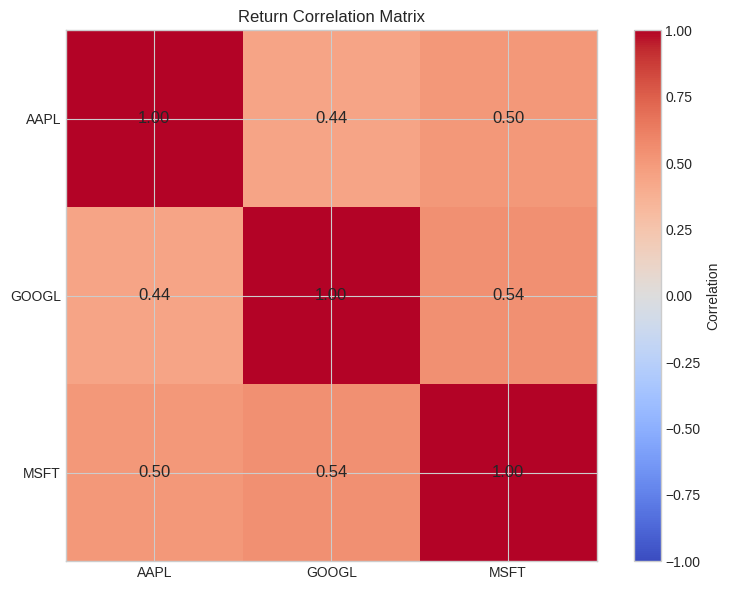

In [8]:
# 计算股票收益率相关性
returns = df_stock.pivot(index='date', columns='ticker', values='ret')

# 计算相关系数矩阵
corr_matrix = returns.corr()
print("收益率相关性矩阵:")
print(corr_matrix.round(3))

# 可视化
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(3), corr_matrix.columns)
plt.yticks(range(3), corr_matrix.columns)
plt.title('Return Correlation Matrix')

# 添加数值标注
for i in range(3):
    for j in range(3):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                 ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

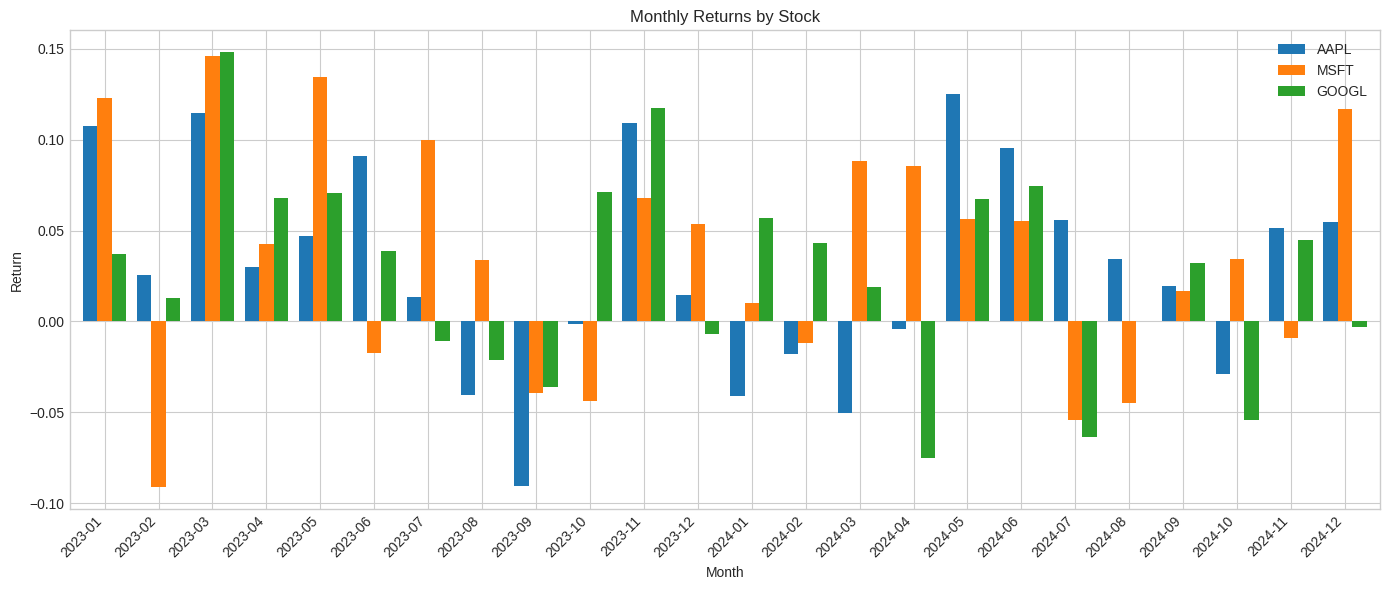

图表已保存: monthly_returns.png


In [11]:
# 计算月度收益率
df_stock['month'] = df_stock['date'].dt.to_period('M')
monthly_ret = df_stock.groupby(['month', 'ticker'])['ret'].sum().unstack()
monthly_ret.index = monthly_ret.index.astype(str)

# 绘制月度收益柱状图（更简单）
monthly_ret.plot(kind='bar', figsize=(14, 6), width=0.8)
plt.title('Monthly Returns by Stock')
plt.xlabel('Month')
plt.ylabel('Return')
plt.legend(['AAPL', 'MSFT', 'GOOGL'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('monthly_returns.png', dpi=150)
plt.show()

print("图表已保存: monthly_returns.png")